# Unrotated Surface code

In [1]:
def circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
    rounds,
    xorder,
    zorder,
    error_rate=0.001,
    cx_error=True,
):
    """
    Unrotated surface code with d=3 but CX split over 8 ticks, doing X and Z separately
    this version is all x and then all z
    X error on ancilla after X type CX only
    logical Z

    
    Parameters
    ----------
    rounds : int
    xorder : list[int]
    zorder : list[int]
    error_rate : float
        Physical error rate used for all error channels.
    cx_error : bool
        If True, include X_ERROR(error_rate) on ancilla after CX .
    """

    dep1 = f"DEPOLARIZE1({0})"
    dep2 = f"DEPOLARIZE2({0})"
    xerr = f"X_ERROR({error_rate})"
   # zerr = f"Z_ERROR({error_rate})"

    cx_noise = f"{xerr}" if cx_error else ""

    c_txt = f"""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(0, 1) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(3, 1) 8
QUBIT_COORDS(4, 1) 9
QUBIT_COORDS(0, 2) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(4, 2) 14
QUBIT_COORDS(0, 3) 15
QUBIT_COORDS(1, 3) 16
QUBIT_COORDS(2, 3) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(0, 4) 20
QUBIT_COORDS(1, 4) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
R 0 2 4 6 8 10 12 14 16 18 20 22 24

R 1 3 5 7 9 11 13 15 17 19 21 23

TICK


H 1 3 11 13 21 23

TICK
"""

    # ---- X stabilizer CX blocks ----
    # no idle error for now
    CX1 = f"""CX 1 2 3 4 11 12 13 14 21 22 23 24
{cx_noise} 1 3 11 13 21 23

TICK
"""
    CX2 = f"""CX 1 6 11 16 3 8 13 18
{cx_noise} 1 11 3 13

TICK
"""
    CX3 = f"""CX 11 6 21 16 13 8 23 18
{cx_noise} 11 21 13 23 

TICK
"""
    CX4 = f"""CX 1 0 11 10 21 20 3 2 13 12 23 22
{cx_noise} 1 11 21 3 13 23 

TICK
"""

    for k in xorder:
        if k == 1:
            c_txt += CX1
        if k == 2:
            c_txt += CX2
        if k == 3:
            c_txt += CX3
        if k == 4:
            c_txt += CX4

    # ---- Z stabilizer CX blocks ----
    CXZ1 = f"""CX 6 5 16 15 8 7 18 17

TICK
"""
    CXZ2 = f"""CX 10 5 20 15 12 7 22 17 14 9 24 19

TICK
"""
    CXZ3 = f"""CX 0 5 10 15 2 7 12 17 4 9 14 19

TICK
"""
    CXZ4 = f"""CX 6 7 16 17 8 9 18 19

TICK
"""

    for k in zorder:
        if k == 1:
            c_txt += CXZ1
        if k == 2:
            c_txt += CXZ2
        if k == 3:
            c_txt += CXZ3
        if k == 4:
            c_txt += CXZ4

    # ---- Measurement & detectors ----
    c_txt += f"""H 1 3 11 13 21 23

TICK

MR 1 3 5 7 9 11 13 15 17 19 21 23

DETECTOR rec[-10]
DETECTOR rec[-5]
DETECTOR rec[-9]
DETECTOR rec[-4]
DETECTOR rec[-8]
DETECTOR rec[-3]
"""

    # ---- Repeat block ----
    if rounds != 1:
        repeat_block = f"""REPEAT {rounds-1} {{
TICK

H 1 3 11 13 21 23

TICK
"""
        for k in xorder:
            repeat_block += [CX1, CX2, CX3, CX4][k-1]
        for k in zorder:
            repeat_block += [CXZ1, CXZ2, CXZ3, CXZ4][k-1]

        repeat_block += f"""H 1 3 11 13 21 23

TICK

MR 1 3 5 7 9 11 13 15 17 19 21 23

DETECTOR rec[-12] rec[-24]
DETECTOR rec[-11] rec[-23]
DETECTOR rec[-10] rec[-22]
DETECTOR rec[-9] rec[-21]
DETECTOR rec[-8] rec[-20]
DETECTOR rec[-7] rec[-19]
DETECTOR rec[-6] rec[-18]
DETECTOR rec[-5] rec[-17]
DETECTOR rec[-4] rec[-16]
DETECTOR rec[-3] rec[-15]
DETECTOR rec[-2] rec[-14]
DETECTOR rec[-1] rec[-13]
}}
"""
        c_txt += repeat_block

    # ---- Final data readout ----
    c_txt += f"""
M 0 2 4 6 8 10 12 14 16 18 20 22 24
DETECTOR rec[-8] rec[-10] rec[-13] rec[-23]
DETECTOR rec[-3] rec[-5] rec[-8] rec[-18]
DETECTOR rec[-7] rec[-9] rec[-10] rec[-12] rec[-22]
DETECTOR rec[-2] rec[-4] rec[-5] rec[-7] rec[-17]
DETECTOR rec[-6] rec[-9] rec[-11] rec[-21]
DETECTOR rec[-1] rec[-4] rec[-6] rec[-16]
OBSERVABLE_INCLUDE(0) rec[-11] rec[-12] rec[-13]
"""

    return stim.Circuit(c_txt)


In [7]:
def circuit_surface_code_unrotated_8tick_all_noise(
    d,
    rounds,
    xorder=(1, 2, 3, 4),
    zorder=(1, 2, 3, 4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0
):
    """
    Unrotated planar surface code on a (2d-1)x(2d-1) grid.
    Qubit indexing: q(x,y) = y*L + x.

    Data qubits: (even,even) and (odd,odd)
    X ancillas : (odd,even)
    Z ancillas : (even,odd)

    CX schedule:
        X stabilizers: ancilla -> data
        Z stabilizers: data -> ancilla

    MR ordering is kept as ascending qubit index of all ancillas, matching:
        MR 1 3 5 7 ... (for d=4 this becomes MR 1 3 5 ... 47)

    Detectors:
        - first round: only Z ancillas
        - middle rounds: ALL ancillas (X and Z)
        - last closure: only Z ancillas 
    """

    L = 2*d - 1
    n = L * L

    dep1 = f"DEPOLARIZE1({error_rate})"
    dep2 = f"DEPOLARIZE2({error_rate})"
    xerr = f"X_ERROR({error_rate})"

    idle_err = f"DEPOLARIZE1({idle_rate})"
    idle_err_cx = f"DEPOLARIZE1({cx_idle_rate})"

    cx_noise = dep2 if cx_error else ""

    def q(x, y):
        return y * L + x

    # classify qubits
    data = []
    x_anc = []
    z_anc = []

    for y in range(L):
        for x in range(L):
            qi = q(x, y)
            if (x % 2 == 0 and y % 2 == 0) or (x % 2 == 1 and y % 2 == 1):
                data.append(qi)
            elif x % 2 == 1 and y % 2 == 0:
                x_anc.append(qi)
            elif x % 2 == 0 and y % 2 == 1:
                z_anc.append(qi)

    all_qubits = list(range(n))

    mr_order = sorted(x_anc + z_anc)
    mr_index = {qq: i for i, qq in enumerate(mr_order)}
    M = len(mr_order)

    # detector sets
    det_first = sorted(z_anc)            # first round only Z
    det_middle = sorted(x_anc + z_anc)   # middle rounds all ancillas
    det_final = sorted(z_anc)            # final closure only Z

    directions = {
        1: (1, 0),    # right
        2: (0, 1),    # down
        3: (0, -1),   # up
        4: (-1, 0),   # left
    }

    def data_neighbors_of_ancilla(a):
        ax = a % L
        ay = a // L
        nbrs = []
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = ax+dx, ay+dy
            if 0 <= nx < L and 0 <= ny < L:
                dq = q(nx, ny)
                if dq in data:
                    nbrs.append(dq)
        return sorted(nbrs)

    def cx_layer(ancillas, direction, ancilla_is_control=True):
        dx, dy = directions[direction]
        pairs = []
        involved = set()

        for a in ancillas:
            ax = a % L
            ay = a // L
            nx, ny = ax + dx, ay + dy

            if 0 <= nx < L and 0 <= ny < L:
                dq = q(nx, ny)
                if dq in data:
                    if ancilla_is_control:
                        pairs.append((a, dq))   # ancilla -> data
                    else:
                        pairs.append((dq, a))   # data -> ancilla
                    involved.add(a)
                    involved.add(dq)

        return pairs, involved

    def format_cx_tick(pairs, involved):
        if not pairs:
            return "TICK\n\n"

        flat = []
        for c, t in pairs:
            flat.append(str(c))
            flat.append(str(t))

        idle = [str(u) for u in all_qubits if u not in involved]

        out = "CX " + " ".join(flat) + "\n"
        if cx_noise:
            out += f"{cx_noise} " + " ".join(flat) + "\n"
        if cx_idle_rate > 0 and idle:
            out += f"{idle_err_cx} " + " ".join(idle) + "\n"
        out += "TICK\n\n"
        return out

    # ------------------- build circuit text -------------------
    c_txt = ""

    for y in range(L):
        for x in range(L):
            c_txt += f"QUBIT_COORDS({x}, {y}) {q(x,y)}\n"
    c_txt += "\n"

    # ---- reset all qubits
    c_txt += "R " + " ".join(map(str, all_qubits)) + "\n"
    c_txt += f"{xerr} " + " ".join(map(str, all_qubits)) + "\n"
    c_txt += "TICK\n\n"

    # ---- H on X ancillas
    if idle_rate > 0:
        idle_list = [str(u) for u in all_qubits if u not in x_anc]
        if idle_list:
            c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

    c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
    c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
    c_txt += "TICK\n\n"

    # ---- 4 CX ticks X stabilizers (ancilla->data)
    for k in xorder:
        pairs, involved = cx_layer(x_anc, k, ancilla_is_control=True)
        c_txt += format_cx_tick(pairs, involved)

    # ---- 4 CX ticks Z stabilizers (data->ancilla)
    for k in zorder:
        pairs, involved = cx_layer(z_anc, k, ancilla_is_control=False)
        c_txt += format_cx_tick(pairs, involved)

    # ---- H back
    if idle_rate > 0:
        idle_list = [str(u) for u in all_qubits if u not in x_anc]
        if idle_list:
            c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

    c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
    c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
    c_txt += "TICK\n\n"

    # ---- MR (fixed order)
    c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"
    c_txt += "MR " + " ".join(map(str, mr_order)) + "\n"
    c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"

    if idle_rate > 0:
        c_txt += f"{idle_err} " + " ".join(map(str, data)) + "\n"

    # ---- first round detectors (ONLY Z ancillas)
    for a in det_first:
        ax, ay = a % L, a // L
        i = mr_index[a]
        rec_term = f"rec[-{M - i}]"
        c_txt += f"DETECTOR({ax}, {ay}, 0) {rec_term}\n"
    c_txt += "\n"

    # ---- repeat block
    if rounds > 1:
        c_txt += f"REPEAT {rounds-1} {{\n"
        c_txt += "TICK\n\n"

        # H
        if idle_rate > 0:
            idle_list = [str(u) for u in all_qubits if u not in x_anc]
            if idle_list:
                c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

        c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
        c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
        c_txt += "TICK\n\n"

        # CX X
        for k in xorder:
            pairs, involved = cx_layer(x_anc, k, ancilla_is_control=True)
            c_txt += format_cx_tick(pairs, involved)

        # CX Z
        for k in zorder:
            pairs, involved = cx_layer(z_anc, k, ancilla_is_control=False)
            c_txt += format_cx_tick(pairs, involved)

        # H back
        if idle_rate > 0:
            idle_list = [str(u) for u in all_qubits if u not in x_anc]
            if idle_list:
                c_txt += f"{idle_err} " + " ".join(idle_list) + "\n"

        c_txt += "H " + " ".join(map(str, x_anc)) + "\n"
        c_txt += f"{dep1} " + " ".join(map(str, x_anc)) + "\n"
        c_txt += "TICK\n\n"

        # MR
        c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"
        c_txt += "MR " + " ".join(map(str, mr_order)) + "\n"
        c_txt += f"{xerr} " + " ".join(map(str, mr_order)) + "\n"

        if idle_rate > 0:
            c_txt += f"{idle_err} " + " ".join(map(str, data)) + "\n"

        # middle-round detectors: ALL ancillas (X+Z) => 24 for d=4
        for a in det_middle:
            ax, ay = a % L, a // L
            i = mr_index[a]
            cur = f"rec[-{M - i}]"
            prev = f"rec[-{2*M - i}]"
            c_txt += f"DETECTOR({ax}, {ay}, 0) {cur} {prev}\n"

        c_txt += "}\n\n"

    # ---- Final data measurement
    c_txt += f"{xerr} " + " ".join(map(str, data)) + "\n"
    c_txt += "M " + " ".join(map(str, data)) + "\n"

    if idle_rate > 0:
        c_txt += f"{idle_err} " + " ".join(map(str, mr_order)) + "\n"

    # map data qubit -> rec
    data_meas_count = len(data)
    data_to_rec = {}
    for idx, dq in enumerate(data):
        data_to_rec[dq] = f"rec[-{data_meas_count - idx}]"

    # final closure detectors (ONLY Z ancillas)
    for a in det_final:
        ax, ay = a % L, a // L
        i = mr_index[a]

        anc_rec = f"rec[-{data_meas_count + (M - i)}]"
        nbrs = data_neighbors_of_ancilla(a)
        terms = [anc_rec] + [data_to_rec[n] for n in nbrs]

        c_txt += f"DETECTOR({ax}, {ay}, 1) " + " ".join(terms) + "\n"

    # logical observable along top row: (0,0),(2,0),...
    logical = [q(x, 0) for x in range(0, L, 2)]
    obs_recs = [data_to_rec[dq] for dq in logical]
    c_txt += "OBSERVABLE_INCLUDE(0) " + " ".join(obs_recs) + "\n"

    return stim.Circuit(c_txt)


In [2]:
import stim

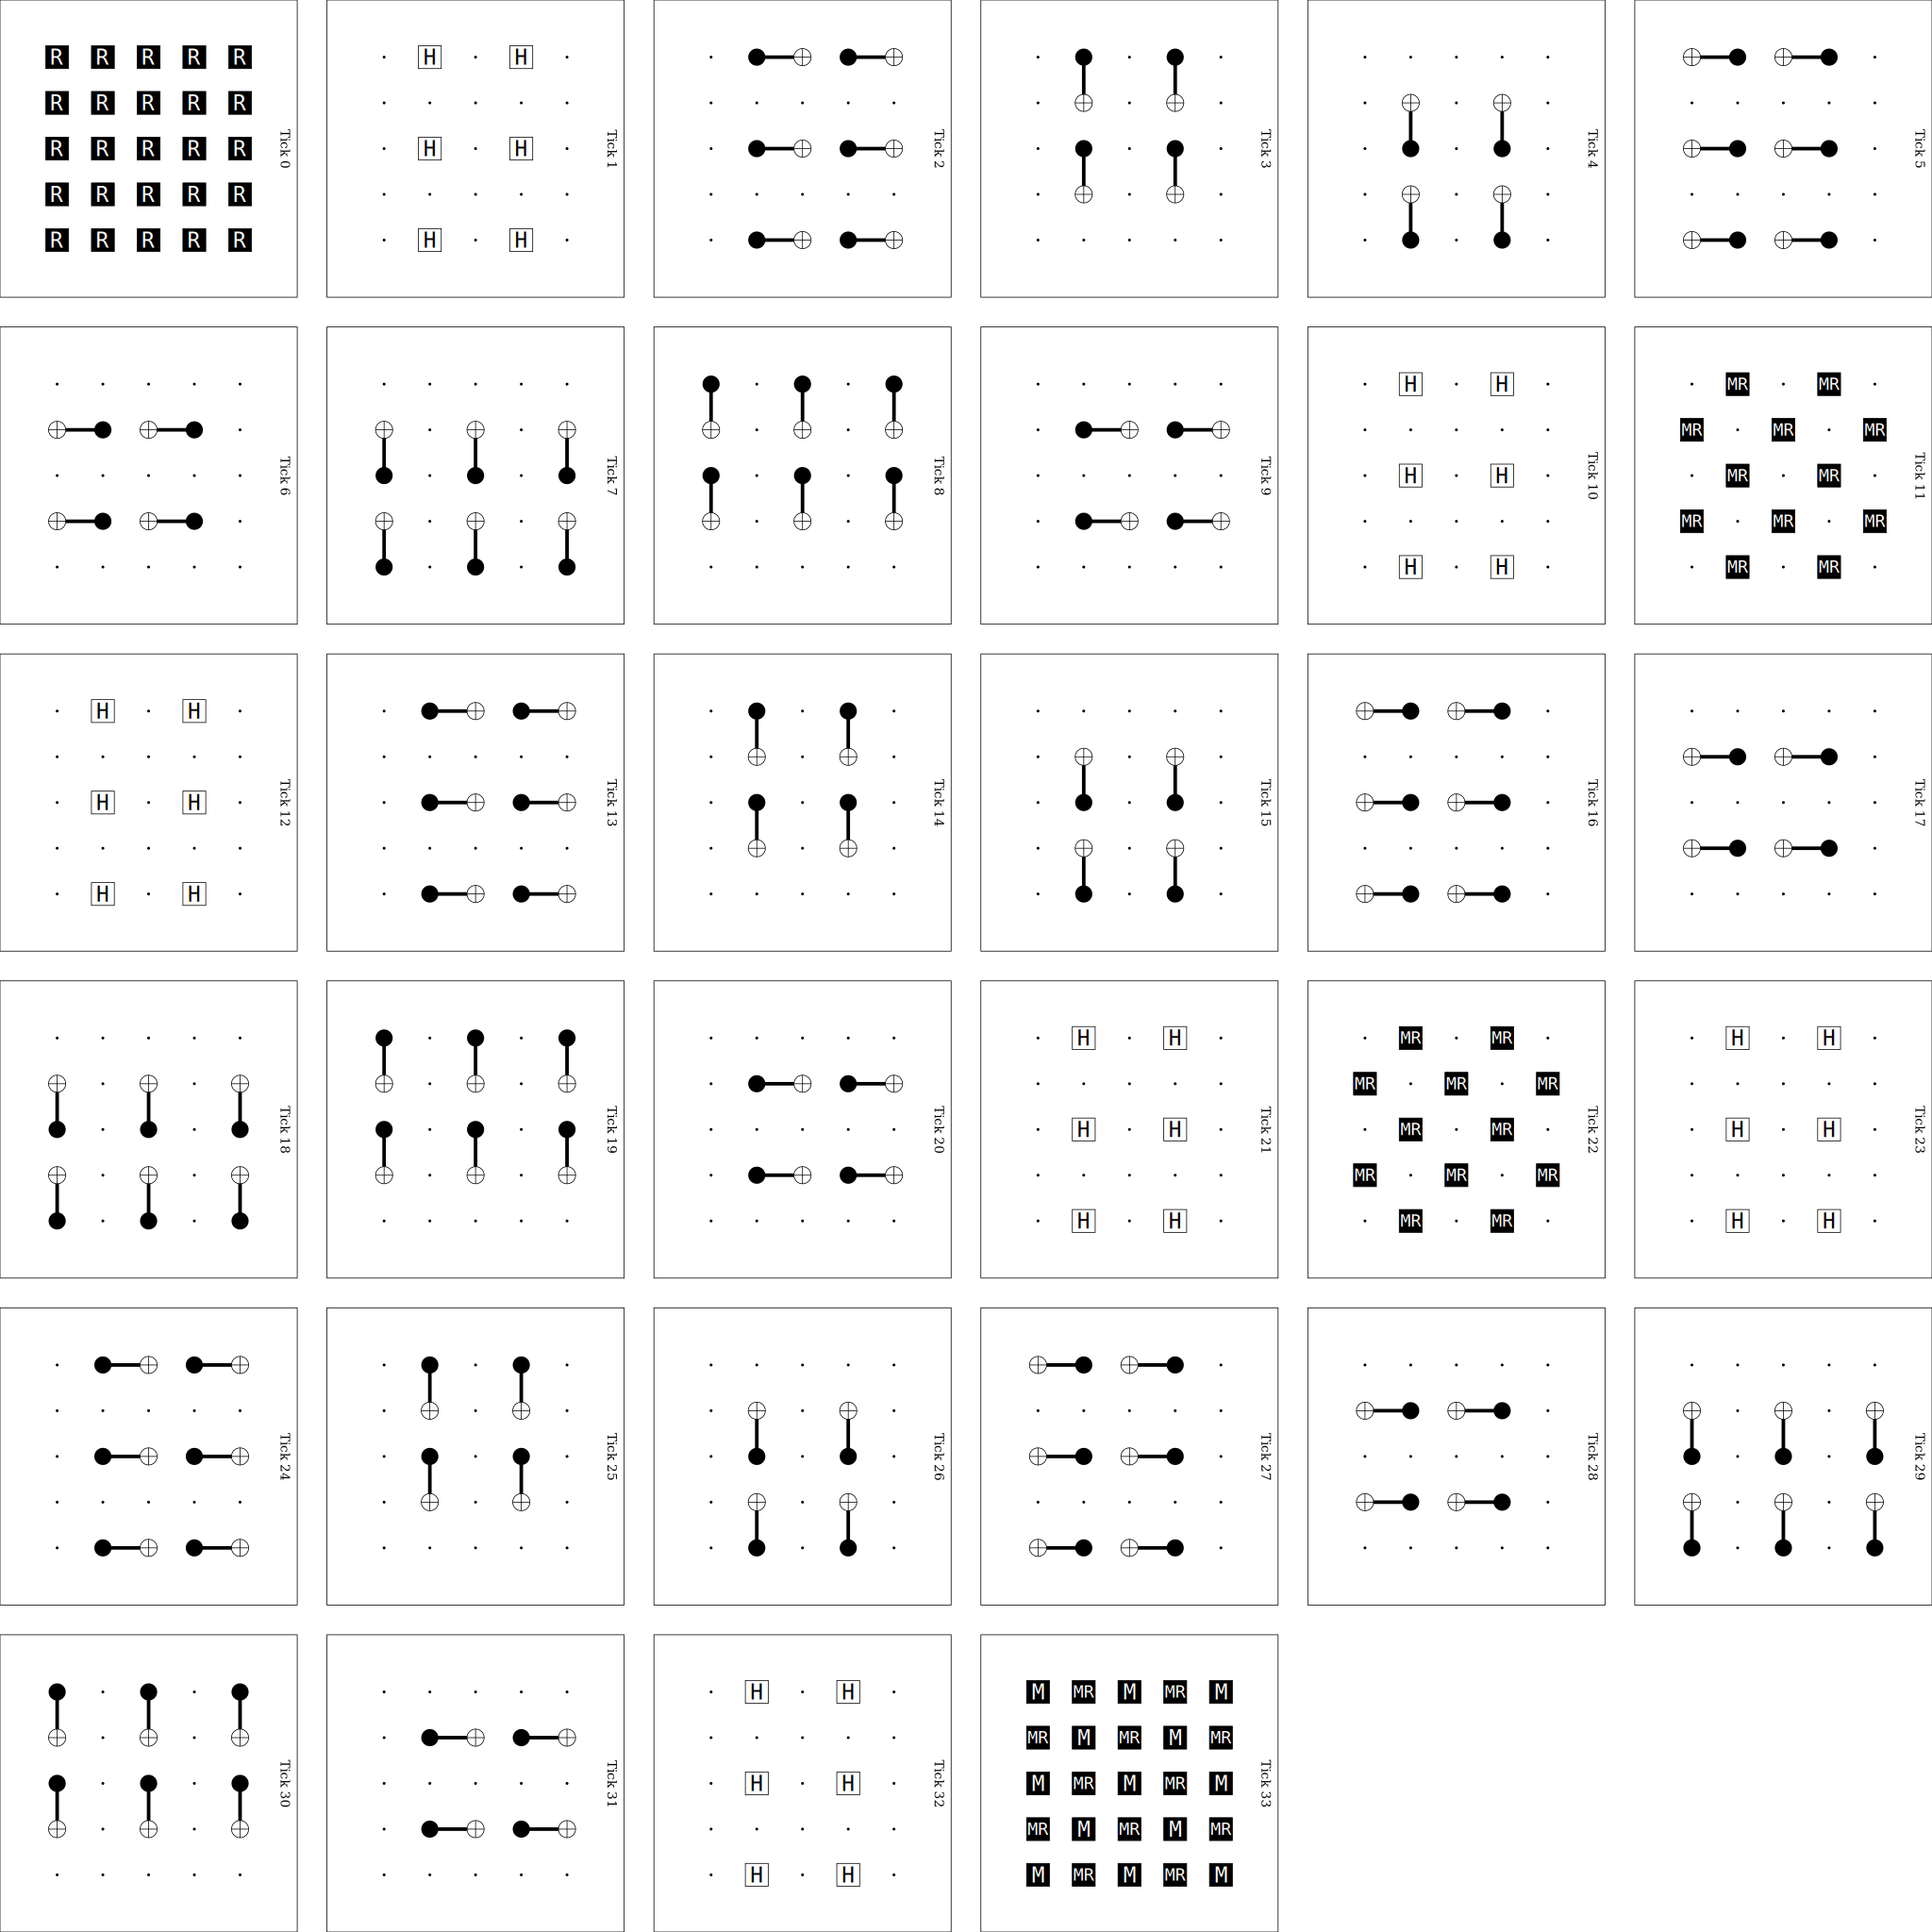

In [4]:
#example circuits (simple noise model)
circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
    3,
    (1,2,3,4),
    (1,2,3,4),
    error_rate=0.001,
    cx_error=True,
).without_noise().diagram("timeslice-svg")

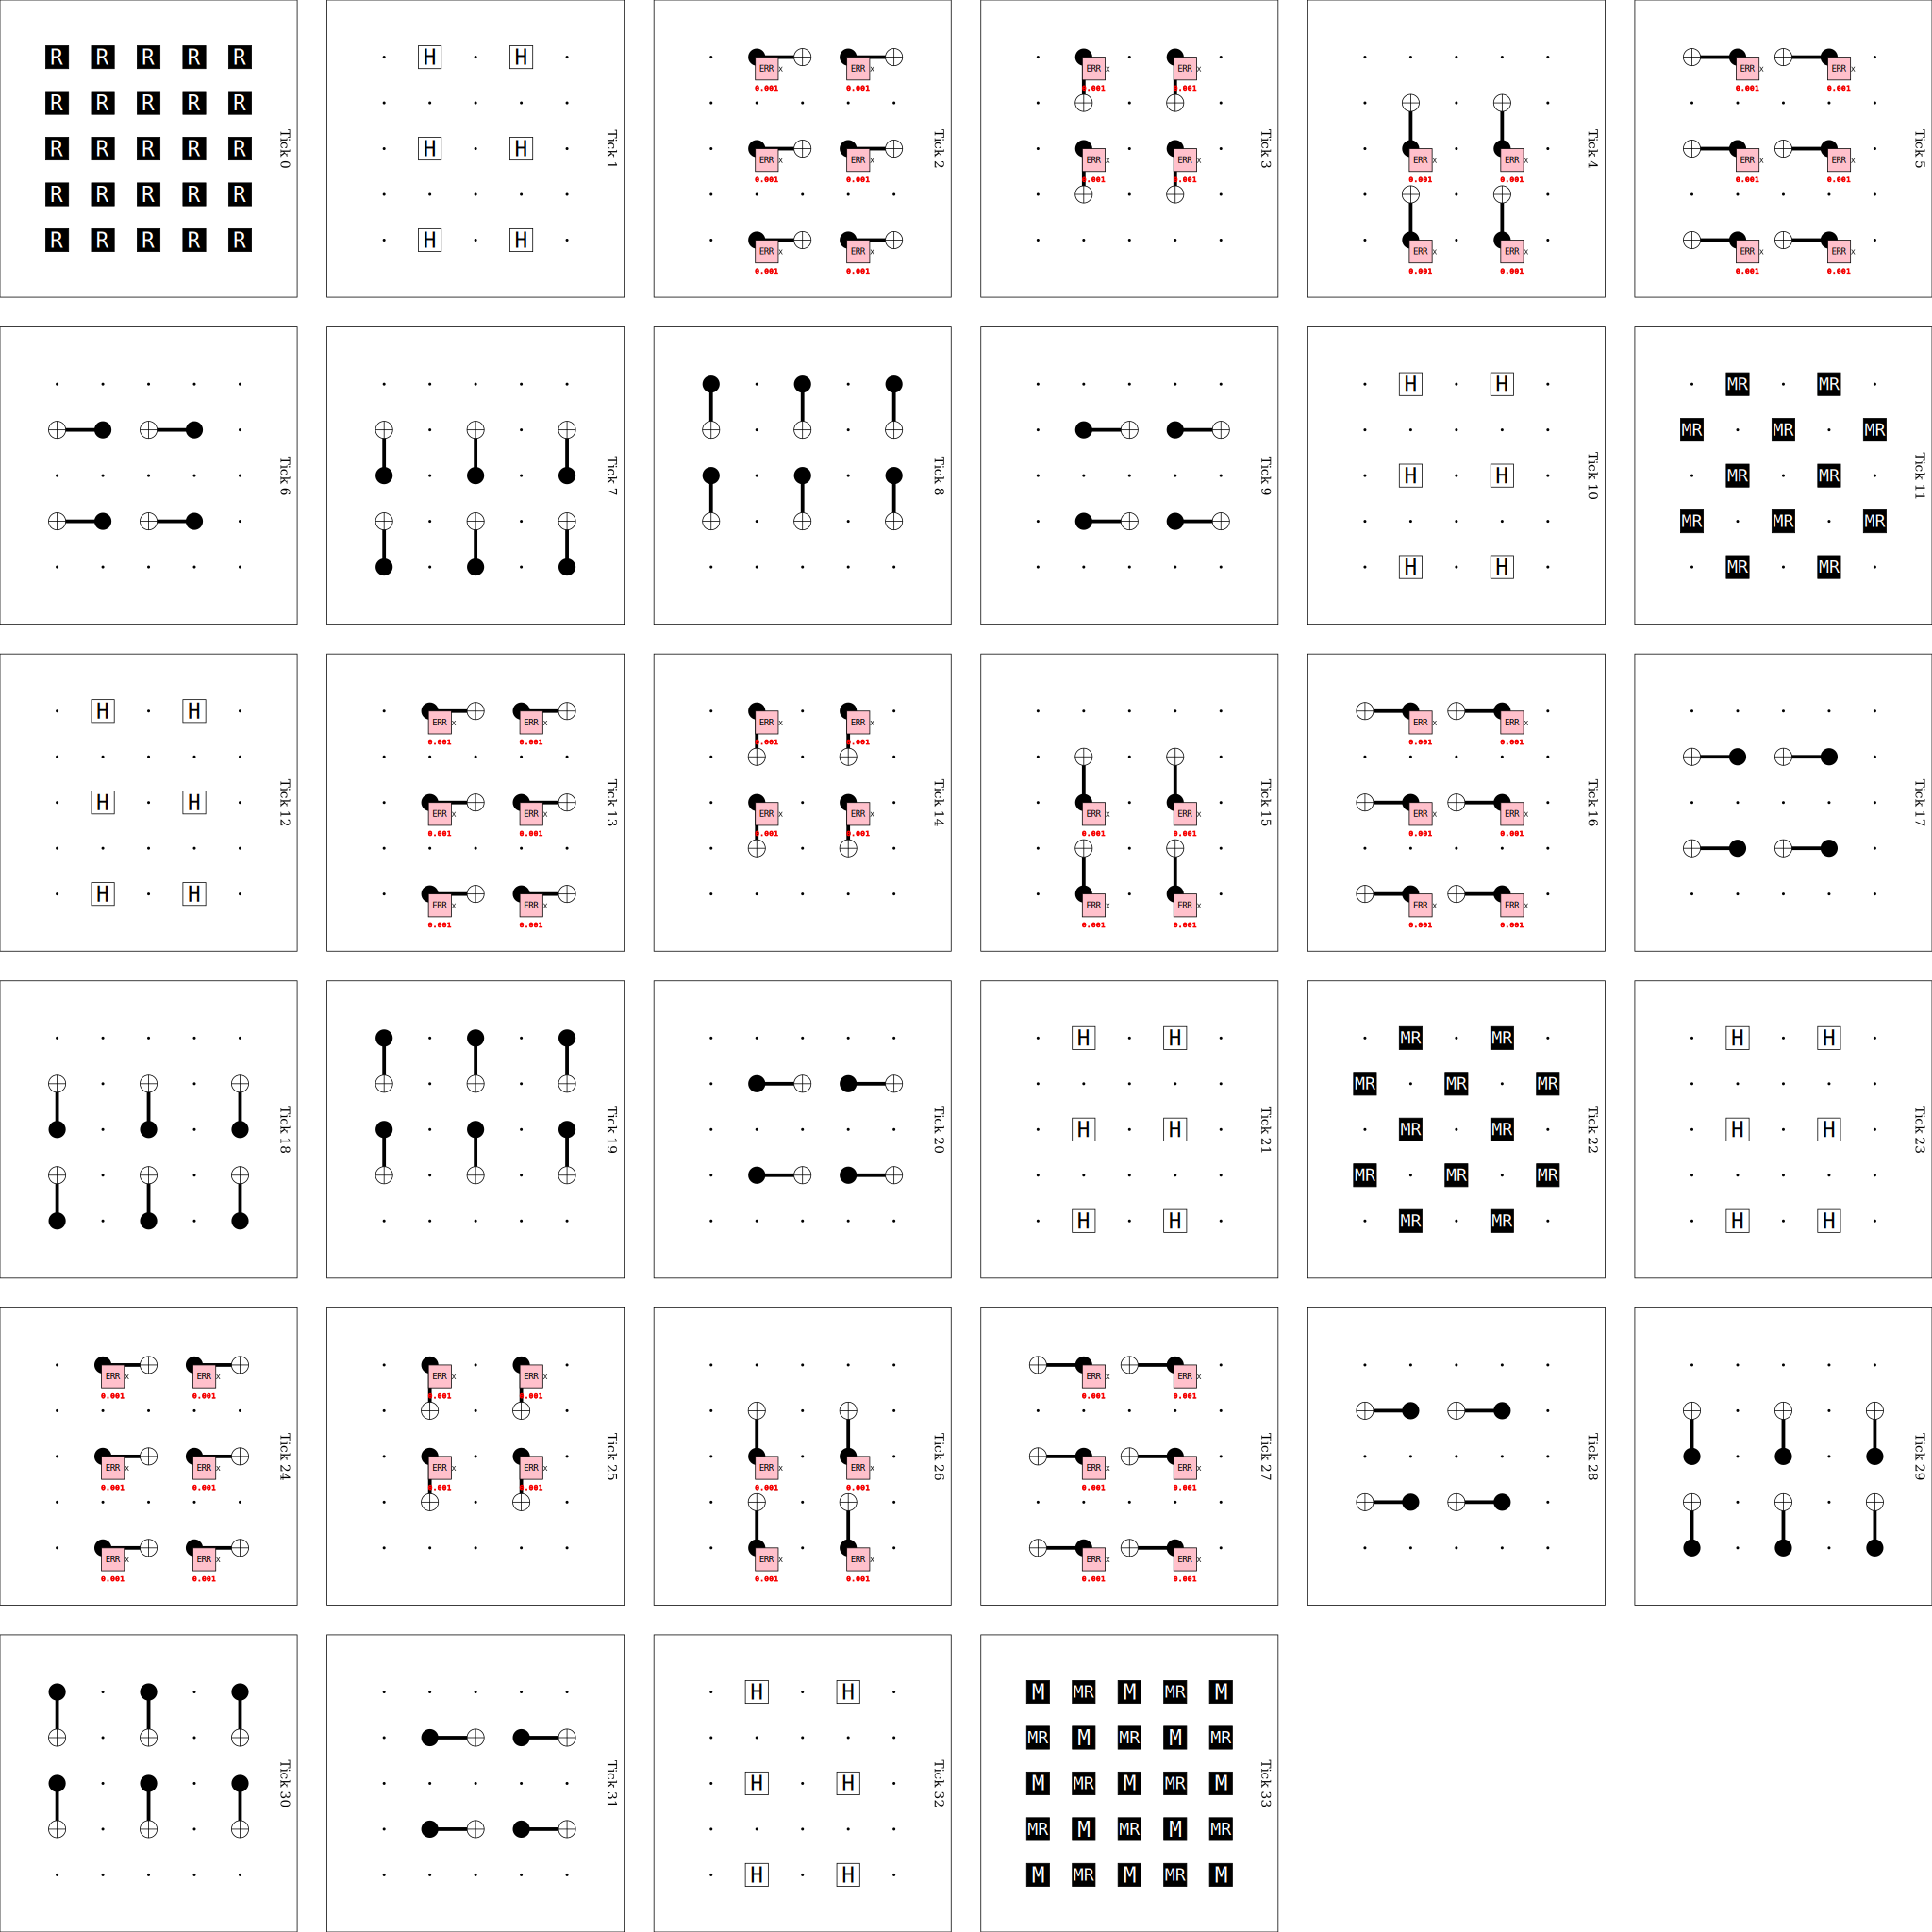

In [5]:
circuit_with_program_txt_8_ticks_x_error_on_ancilla_only(
    3,
    (1,2,3,4),
    (1,2,3,4),
    error_rate=0.001,
    cx_error=True,
).diagram("timeslice-svg")

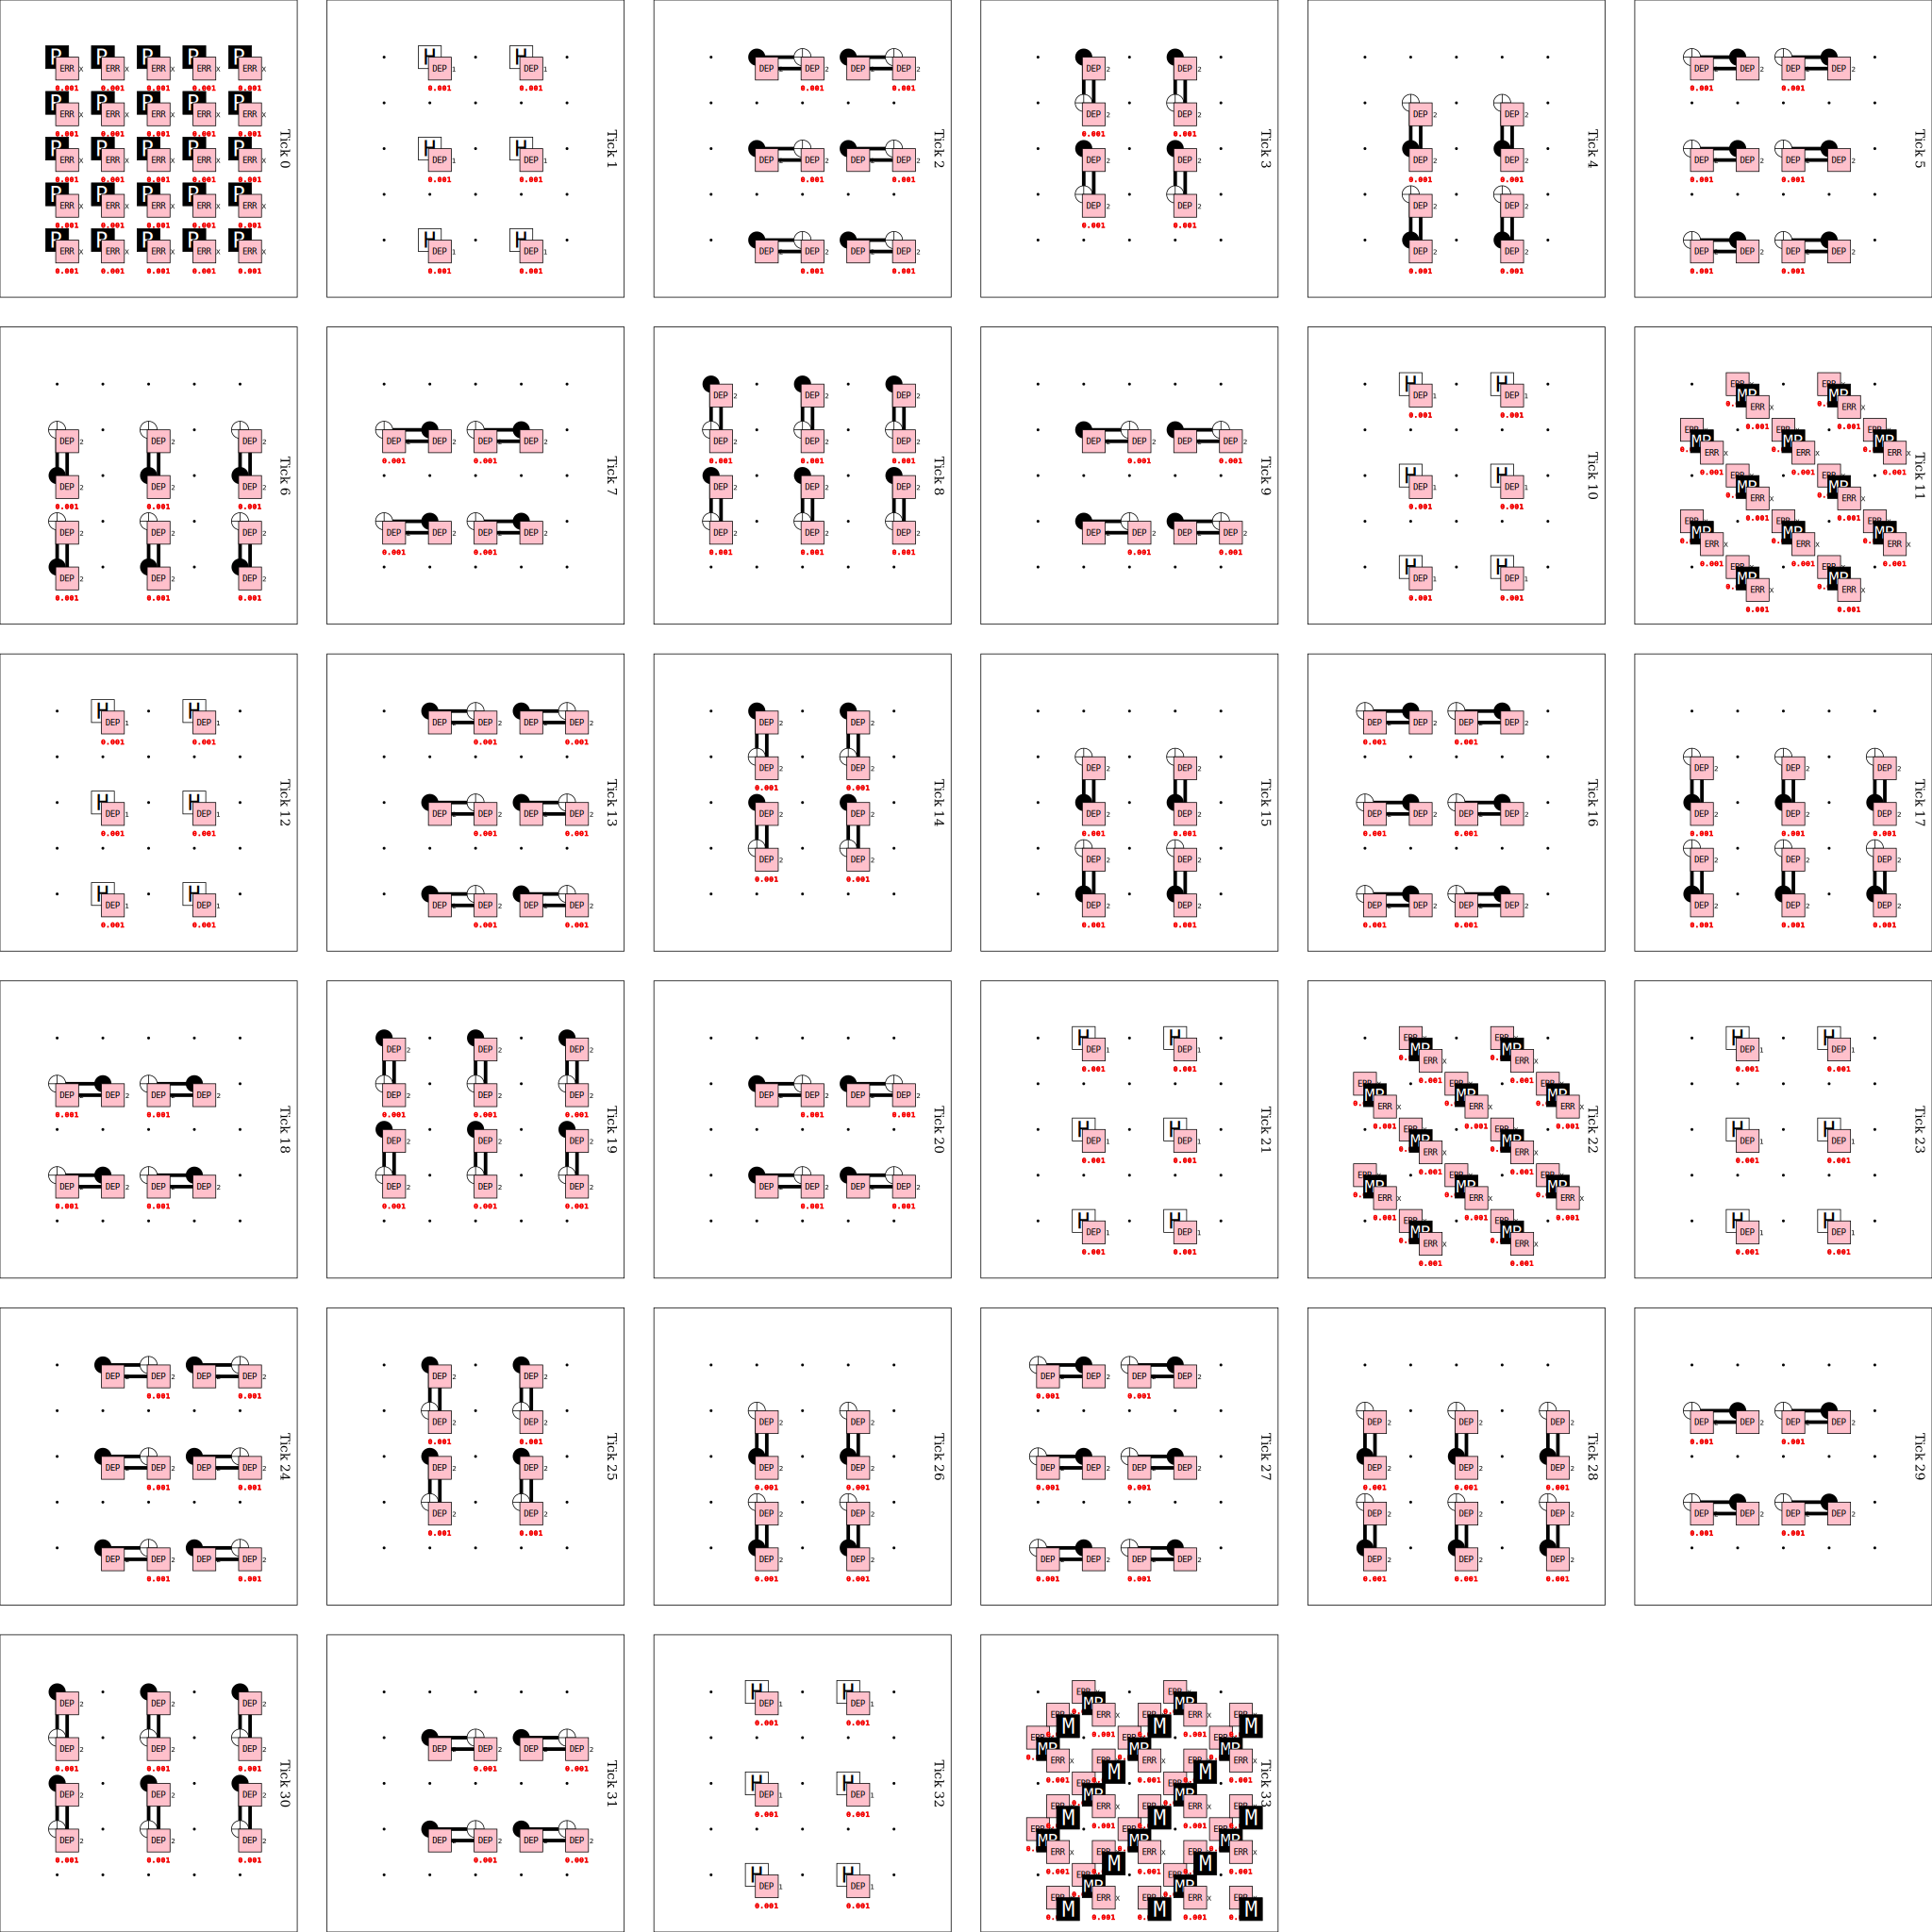

In [11]:
#example circuit (realistic noise model, unrotated surface code)
circuit_surface_code_unrotated_8tick_all_noise(
    3,
    3,
    xorder=(1, 2, 3, 4),
    zorder=(2, 1, 3, 4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0
).diagram("timeslice-svg")

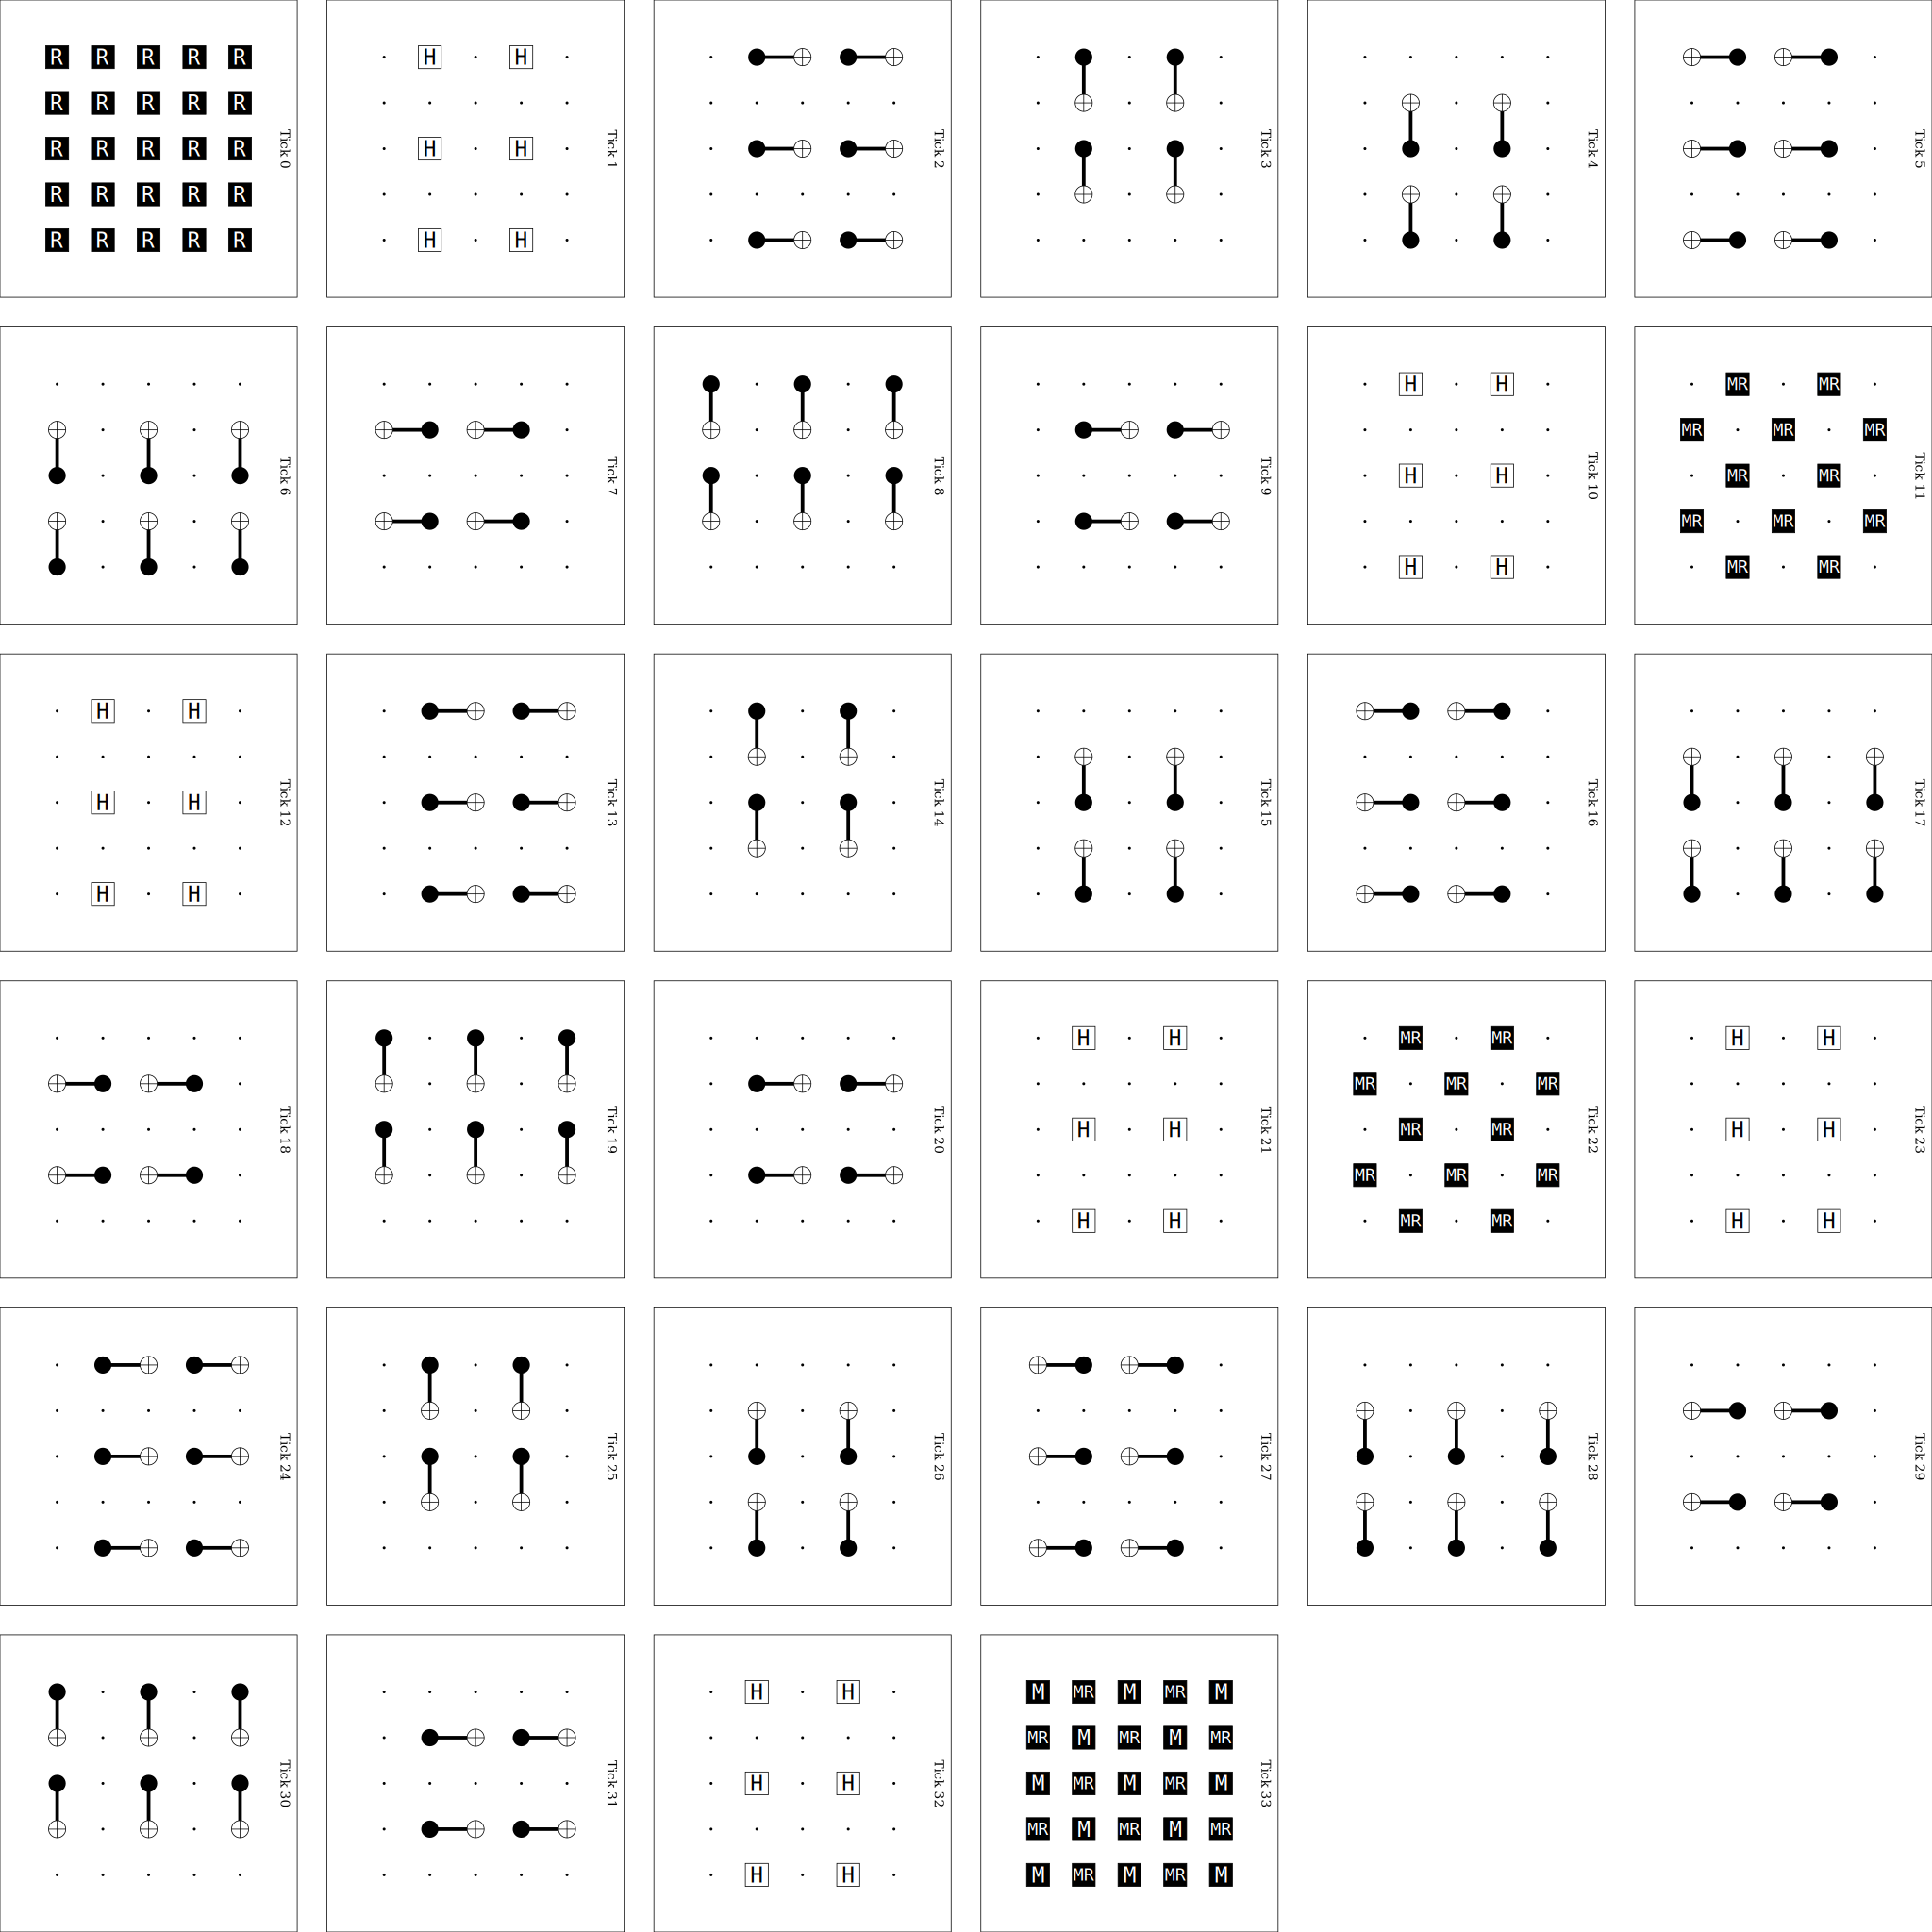

In [13]:
circuit_surface_code_unrotated_8tick_all_noise(
    3,
    3,
    xorder=(1, 2, 3, 4),
    zorder=(2, 1, 3, 4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0
).without_noise().diagram("timeslice-svg")

# Colour code

In [24]:

def circuit_triangular_color_code_z_stabilizers_v2(
    d,
    rounds,
    bulk_cx_order=(1, 2, 3, 4, 5, 6),
    boundary_cx_order=(1, 2, 3, 4, 5, 6),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0,
    cx_idle_rate=0.0,
):
    """
    Generate a triangular color code circuit measuring ONLY Z stabilizers,
    with independently controllable gate orderings for bulk (weight-6) and
    boundary (weight-4) stabilizers, a flexible noise model, and Chromobius
    detector annotations.

    ── Geometry ──────────────────────────────────────────────────────────────
    Let sc = 3*(d-1)//2 + 1  (sc=4 for d=3, sc=7 for d=5, sc=10 for d=7).
    sc rows (y=0 ... sc-1); row y has (sc-y) qubits at x = y/2, y/2+1, ...
    Total: sc*(sc+1)//2 qubits  (10 for d=3, 28 for d=5).

    Ancilla classification by (2j+y) % 6  in  {1,4}  (j = column index).
    Ancilla weight = number of in-grid data neighbors across all 6 directions:
        Weight-6 (bulk)     : all 6 hex neighbors exist  -> interior hexagons
        Weight-4 (boundary) : 4 of 6 neighbors exist     -> edge hexagons
    Note: for d=3 all ancillas are weight-4 (no interior hexagons exist).

    ── The 6 hexagonal CX directions ─────────────────────────────────────────
    (dx, dy) from ancilla towards its data neighbor:
        1: (+1,    0)   east        4: (-1,    0)   west
        2: (+0.5, +1)   south-east  5: (-0.5, +1)   south-west
        3: (+0.5, -1)   north-east  6: (-0.5, -1)   north-west

    CX convention: data -> ancilla  (data is control; Z-stabilizer measurement).

    ── Gate ordering parameters ───────────────────────────────────────────────
    bulk_cx_order     : 6-tuple, permutation of (1,2,3,4,5,6).
    boundary_cx_order : 6-tuple, permutation of (1,2,3,4,5,6).

    ── Circuit structure (matches stim's color_code:memory_xyz for r=rounds) ──
    REPEAT (rounds-1) { syndrome round, NO detectors }
    DETECTOR (2-record) after REPEAT — compares last 2 anc rounds
    Unrolled last syndrome round
    SHIFT_COORDS(0, 0, 1)
    DETECTOR (3-record) — compares last 3 anc rounds
    X_ERROR data, M data
    Closure DETECTORs
    OBSERVABLE_INCLUDE(0)

    ── Chromobius detector annotations ───────────────────────────────────────
    Every DETECTOR carries a 4th coordinate:
        3: red Z,  4: green Z,  5: blue Z
    Colour = column index j = x - y/2  (mod 3).

    Parameters
    ----------
    d : int
        Code distance (odd integers >= 3 recommended).
    rounds : int
        Total syndrome measurement rounds (>= 2).
    bulk_cx_order : tuple of 6 ints in 1..6
    boundary_cx_order : tuple of 6 ints in 1..6
    error_rate : float
    cx_error : bool
    idle_rate : float
    cx_idle_rate : float

    Returns
    -------
    stim.Circuit
    """

    xerr      = f"X_ERROR({error_rate})"
    dep2      = f"DEPOLARIZE2({error_rate})" if cx_error      else ""
    dep1_idle = f"DEPOLARIZE1({idle_rate})"   if idle_rate    > 0 else ""
    dep1_cx   = f"DEPOLARIZE1({cx_idle_rate})" if cx_idle_rate > 0 else ""

    directions = {
        1: ( 1.0,  0),   # east
        2: ( 0.5,  1),   # south-east
        3: ( 0.5, -1),   # north-east
        4: (-1.0,  0),   # west
        5: (-0.5,  1),   # south-west
        6: (-0.5, -1),   # north-west
    }

    # ── Qubit layout ──────────────────────────────────────────────────────
    sc = 3 * (d - 1) // 2 + 1
    coords_list = []
    for y in range(sc):
        for j in range(sc - y):
            coords_list.append((j + y / 2, y))

    n_total      = len(coords_list)
    coord_to_idx = {c: i for i, c in enumerate(coords_list)}
    all_qubits   = list(range(n_total))

    def qubit_at(x, y):
        return coord_to_idx.get((x, y), None)

    def fmt(v):
        return int(v) if v == int(v) else v

    # ── Classify qubits ───────────────────────────────────────────────────
    data_set = set()
    anc_set  = set()
    for i, (x, y) in enumerate(coords_list):
        j   = x - y / 2
        val = int(round(2 * j + y)) % 6
        (anc_set if val in (1, 4) else data_set).add(i)

    data     = sorted(data_set)
    # mr_order: sorted by qubit INDEX (determines MR instruction and record offsets)
    mr_order = sorted(anc_set)
    mr_index = {a: i for i, a in enumerate(mr_order)}
    M        = len(mr_order)

    # CX pair display order: sort ancs by coordinate (x asc, then y asc)
    def anc_coord_key(a):
        ax, ay = coords_list[a]
        return (ax, ay)

    mr_cx_order = sorted(anc_set, key=anc_coord_key)

    # ── Chromobius 4th coordinate ─────────────────────────────────────────
    def anc_4th(a):
        ax, ay = coords_list[a]
        j = int(round(ax - ay / 2))
        return j % 3 + 3

    # ── CX pairs per direction per ancilla ────────────────────────────────
    anc_active_dirs = {}
    for a in mr_order:
        ax, ay = coords_list[a]
        active = set()
        for k, (dx, dy) in directions.items():
            dq = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                active.add(k)
        anc_active_dirs[a] = active

    bulk_ancs     = [a for a in mr_cx_order if len(anc_active_dirs[a]) == 6]
    boundary_ancs = [a for a in mr_cx_order if len(anc_active_dirs[a]) == 4]

    def build_pairs(ancilla_list, direction_key):
        dx, dy = directions[direction_key]
        pairs  = []
        for a in ancilla_list:
            if direction_key not in anc_active_dirs[a]:
                continue
            ax, ay = coords_list[a]
            dq     = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                pairs.append((dq, a))   # data -> ancilla
        return pairs

    cx_pairs_bulk     = {k: build_pairs(bulk_ancs,     k) for k in range(1, 7)}
    cx_pairs_boundary = {k: build_pairs(boundary_ancs, k) for k in range(1, 7)}

    def neighbors_of_desc(a):
        """Data neighbors of ancilla a, sorted DESCENDING by qubit index."""
        ax, ay = coords_list[a]
        nbrs   = []
        for k, (dx, dy) in directions.items():
            dq = qubit_at(ax + dx, ay + dy)
            if dq is not None and dq in data_set:
                nbrs.append(dq)
        return sorted(nbrs, reverse=True)

    # ── One combined CX tick ──────────────────────────────────────────────
    def syndrome_tick(step):
        bk = bulk_cx_order[step]
        bd = boundary_cx_order[step]
        pairs = cx_pairs_bulk[bk] + cx_pairs_boundary[bd]

        if not pairs:
            if dep1_cx:
                return f"{dep1_cx} {' '.join(map(str, all_qubits))}\nTICK\n\n"
            return "TICK\n\n"

        flat     = " ".join(f"{c} {t}" for c, t in pairs)
        involved = set(q for p in pairs for q in p)
        out      = f"CX {flat}\n"
        if dep2:
            out += f"{dep2} {flat}\n"
        if dep1_cx:
            idle = sorted(set(all_qubits) - involved)
            if idle:
                out += f"{dep1_cx} " + " ".join(map(str, idle)) + "\n"
        out += "TICK\n\n"
        return out

    # ── One full syndrome round ────────────────────────────────────────────
    def syndrome_round():
        t = ""
        for step in range(6):
            t += syndrome_tick(step)
        mr_str = " ".join(map(str, mr_order))
        t += f"{xerr} {mr_str}\nMR {mr_str}\n{xerr} {mr_str}\n"
        if dep1_idle:
            t += f"{dep1_idle} " + " ".join(map(str, data)) + "\n"
        return t

    # ── Middle detectors (2-record) ────────────────────────────────────────
    def middle_detectors_2rec():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            t += f"DETECTOR({fmt(ax)}, {ay}, 0, {anc_4th(a)}) rec[-{M-i}] rec[-{2*M-i}]\n"
        return t

    # ── Middle detectors (3-record, for last unrolled round) ───────────────
    def middle_detectors_3rec():
        t = ""
        for a in mr_order:
            ax, ay = coords_list[a]
            i      = mr_index[a]
            t += f"DETECTOR({fmt(ax)}, {ay}, 0, {anc_4th(a)}) rec[-{M-i}] rec[-{2*M-i}] rec[-{3*M-i}]\n"
        return t

    # ── Assemble circuit ───────────────────────────────────────────────────
    c = ""

    for i, (x, y) in enumerate(coords_list):
        c += f"QUBIT_COORDS({fmt(x)}, {y}) {i}\n"
    c += "\n"

    all_q_str = " ".join(map(str, all_qubits))
    c += f"R {all_q_str}\n{xerr} {all_q_str}\n"

    # REPEAT (rounds-1): syndrome rounds with NO detectors
    c += f"REPEAT {rounds - 1} {{\n"
    c += "TICK\n\n"
    c += syndrome_round()
    c += "}\n"

    # 2-record detectors after REPEAT (compare last 2 rounds from REPEAT)
    c += middle_detectors_2rec()
    c += "\n"

    # Unrolled last middle round
    c += "TICK\n\n"
    c += syndrome_round()
    c += "\n"

    # SHIFT_COORDS + 3-record detectors
    c += "SHIFT_COORDS(0, 0, 1)\n"
    c += middle_detectors_3rec()
    c += "\n"

    # Final data measurement
    data_str = " ".join(map(str, data))
    c += f"{xerr} {data_str}\nM {data_str}\n"

    n_data   = len(data)
    data_rec = {dq: n_data - idx for idx, dq in enumerate(data)}

    # Closure detectors: neighbors sorted DESCENDING, then anc LAST
    for a in mr_order:
        ax, ay   = coords_list[a]
        anc_off  = n_data + (M - mr_index[a])
        nbr_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in neighbors_of_desc(a))
        c += f"DETECTOR({fmt(ax)}, {ay}, 1, {anc_4th(a)}) {nbr_recs} rec[-{anc_off}]\n"

    # Observable: logical Z along bottom row, sorted DESCENDING
    logical  = sorted(
        (i for i, (x, y) in enumerate(coords_list) if y == 0 and i in data_set),
        reverse=True
    )
    obs_recs = " ".join(f"rec[-{data_rec[dq]}]" for dq in logical)
    c += f"OBSERVABLE_INCLUDE(0) {obs_recs}\n"

    return stim.Circuit(c)



In [15]:
import stim

In [26]:
circuit=circuit_triangular_color_code_z_stabilizers_v2(
    5,
    3,
    bulk_cx_order=(1, 3, 4, 2, 6, 5),
    boundary_cx_order=(2, 5, 3, 6, 1, 4),
    error_rate=0.001,
    cx_error=True,
    idle_rate=0.0001,
    cx_idle_rate=0.00001,
)

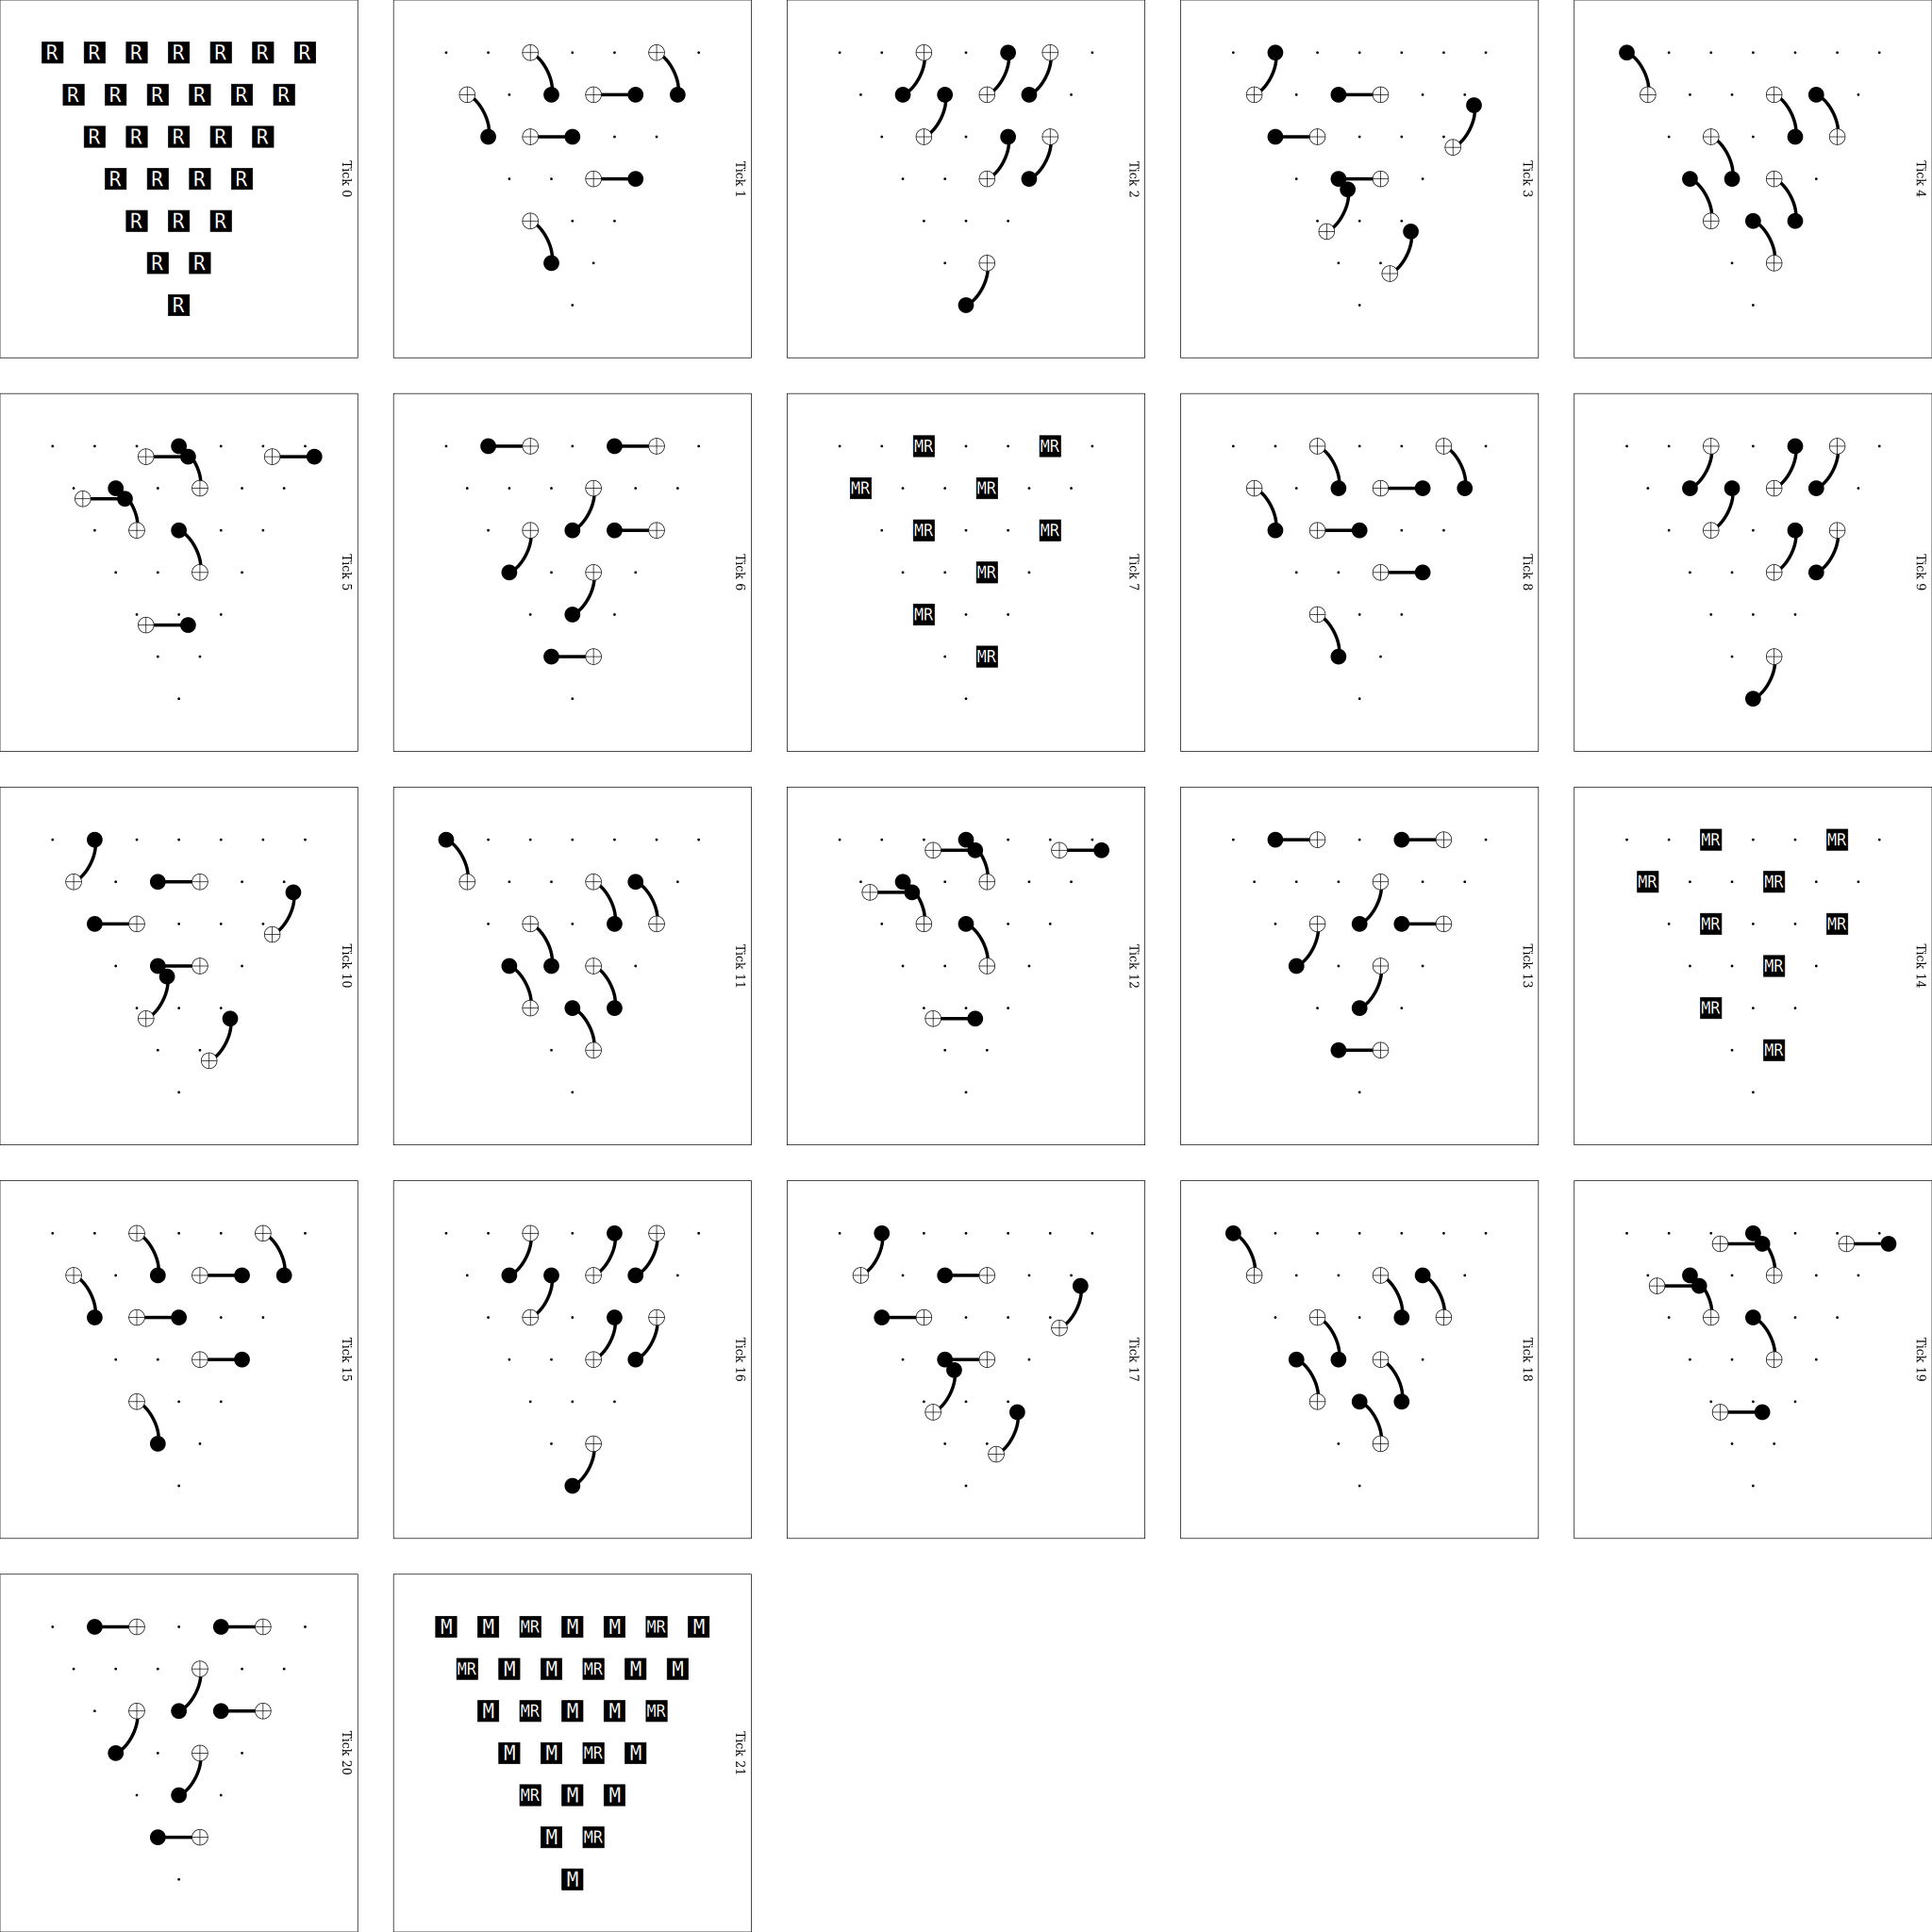

In [27]:
circuit.without_noise().diagram("timeslice-svg")

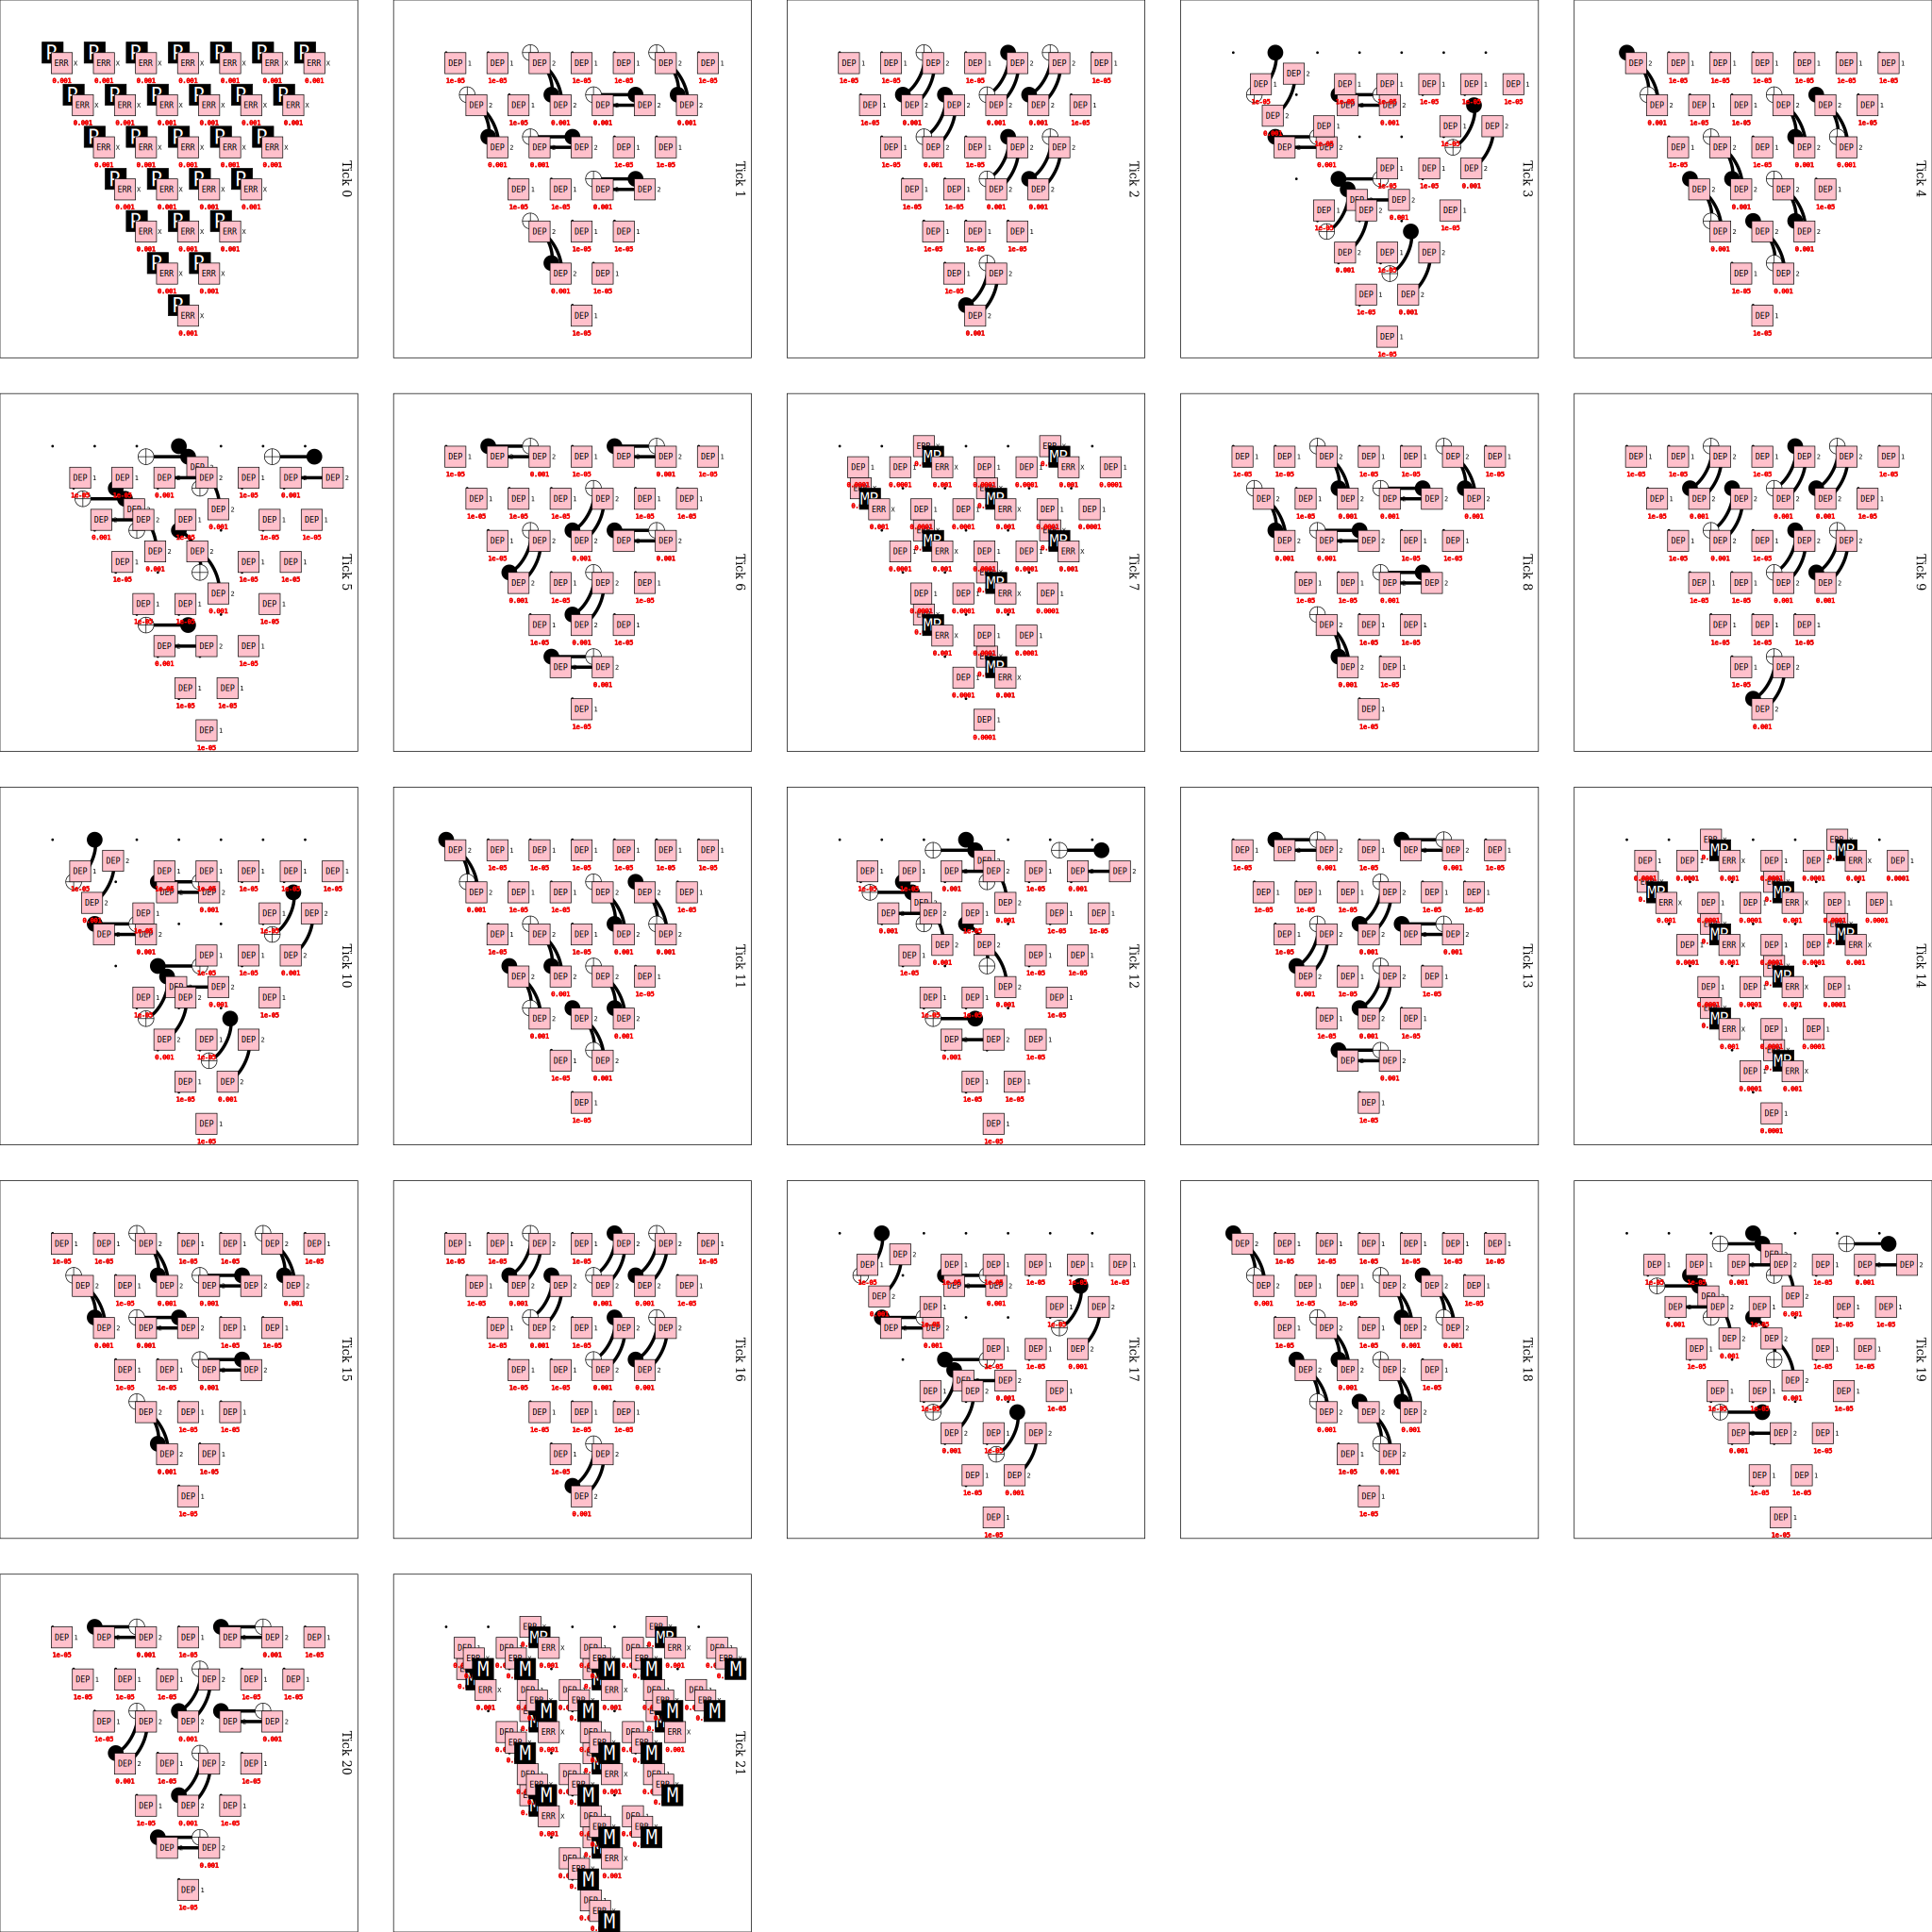

In [29]:
circuit.diagram("timeslice-svg")